# Part A: Building point-based validation metrics

## Objective
Given a WRF grid cell and its nearest Fire Emergency New Zealand weather station,
build validation toolkit to calculate validation metrics illustrated in the reading material
handout. The coefficient of determination, root mean square error, and the index of
agreement. The meteorological variables we will be validating for are wind speed, air
temperature, and relative humidity. Produce a well commented (using markdown and in-cell
comments) Jupyter notebook sections that full fill the following requirements.
1. For your observational stations you will use two FENZ weather station locations.
a. Godley Head (a coastal site in Canterbury with complex topography)
b. Darfield, Forest Plains (a flat terrain site inland Canterbury)
2. Use a week of your choice in January and a week in July to extract the time series from a WRF
grid point and the nearest FENZ weather station. Your choice of the week and year should
ensure data availability from the weather station (real data will have data availability issues,
double check your choice)
3. Write code that calculates the RMSE, IOA, and R-square validation metrics. Your n (refer to the
reading material document) should be the total number of observations in the week period.
Report your results using a table.
4. Produce time series plots of observed and modelled meteorological variables at both
locations. Your plots should demonstrate a one to one comparison and their objective is to
visualize the trend and biases while investigating the actual data without summary error
statistics yet. Describe and discuss your results.
5. Produce scatter plots of observed and modelled meteorological variables for both locations.
Add a linear trend line that best fits the data points and report the equation of the line. For
reference this is similar to the green lines in the case studies presented in the reading material
handout. Describe and discuss your results.

* One weather station will probably perform better than the other
* Godley Head was chosen because of its complex terrain
* The weather model has 4km resolution but the GH headland is only 1.3km across so the resolution probably won't accurately represent it
* Wind Atlas - resource for 1km wind model


NEW Stations:

Southbridge 02139bfc0beb28e0229b756e 172.25856, -43.84945
Glentanner b1ccc6ead3273d01c94501bd  170.12862, -43.91498

## Set current working directory - NOTE! you may need to change or remove this

The code that lods the AWS files assumes they will be in the same directory as this notebook. If the file loading cells below fail to find the files then edit or remove this cell.

In [40]:
%cd /home/UOCNT/tco111/GISC405

/home/UOCNT/tco111/GISC405


### Import libraries

In [41]:
pip install HydroErr

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install dask

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import xarray as xr
import os
from time import time
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from pathlib import Path
from scipy import stats
import glob

### Define constants

In [2]:
OWNER = "FENZ"

SOUTHBRIDGE = {
    'filename': "southbridge_aws.nc",
    'station_id': "02139bfc0beb28e0229b756e",
    'location': { 'lon': 172.25856, 'lat': -43.84945 }
}
GLENTANNER = {
    'filename': "glentanner_aws.nc",
    'station_id': "b1ccc6ead3273d01c94501bd",
    'location': { 'lon': 170.12862, 'lat': -43.91498 }
}
STATIONS = {
    'Southbridge': SOUTHBRIDGE,
    'Glentanner': GLENTANNER,
}

PARAMETERS = ['wind_speed', 'relative_humidity', 'temperature' ]
VARIABLES = ['wind_speed', 'relative_humidity', 'air_temperature' ]

DATE_RANGES = [
  { 'start_date': "2020-01-06", 'end_date': "2020-01-12" },
  { 'start_date': "2019-07-10", 'end_date': "2019-07-16" },
]

AXIS_LABEL_FONT_SIZE = 8
TITLE_FONT_SIZE = 12

## Define some utility functions

`calc_wind_speed` calculates overall wind speed from the North-South and the East-West wind speed values.

In [3]:
def calc_wind_speed(u, v):
  usqr = u ** 2
  vsqr = v ** 2

  # Wind speed calculation is the square root of the sum of the squares
  return np.sqrt(usqr + vsqr)

`plot_model_vs_observations` creates a graph of the predicted and observed data for one variable over one time period

In [3]:
def plot_model_vs_observations(model_data, obs_data, key, month, data_type, ax):
    model_data.plot(ax=ax, linestyle="dashed",color="blue",label="Model")
    obs_data.plot(ax=ax, linestyle="dashed",color="orange",label="Observed")
    ax.set_xlabel("Time", fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_ylabel(data_type, fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_title(f"{data_type}, {key}, {month}")
    ax.legend()

`to_nz_time` converts UTC data to NZ timezone

In [2]:
def to_nz_time(ds):
    months = ds['time'].dt.month
    is_summer_time = (months >= 4) & (months <= 9)

    shift_12h = np.timedelta64(12, 'h')
    shift_13h = np.timedelta64(13, 'h')

    nz_offsets = np.where(is_summer_time, shift_12h, shift_13h)

    local_times = ds['time'].values + nz_offsets
    ds = ds.drop_vars('time')
    ds = ds.assign_coords(time=(['time'], local_times))
    
    return ds

## Q1: Loading the data

> For your observational stations you will use two FENZ weather station locations. The data files
> are in the assignment dropbox (glentanner_aws.nc, and southbridge_aws.nc)
> a. Glentanner (a mountainous site in Mackenzie)
> b. Southbridge (a flat terrain site in Canterbury

This code loads the two provided data files into an XArray dataset, and stores it in the STATIONS dictionary, for use by subsequent code cells.

In [47]:
import os
print(os.getcwd())

/home/UOCNT/tco111/GISC405


In [48]:
for k_ix, key in enumerate(STATIONS.keys()):
    stn = STATIONS[key]
    file_path = stn["filename"]
    dataset = xr.open_dataset(f'./{file_path}')
    dataset = to_nz_time(dataset)
    stn['dataset'] = dataset

## Q2: Extract time series for January and July

> Use a week of your choice in January and a week in July to extract the time series from a WRF
> grid point and the nearest FENZ weather station.

The function 'extract_model_series' loads a time slice from the WRF data for a given data type (i.e. 'RH' or 'T') for the given lat/lon location.

In [49]:
def extract_model_series(data_type, start_date, end_date, location, height=2):
    date_obj = datetime.strptime(start_date, "%Y-%m-%d")

    # If looking for wind speed data, we need to calculate it from the two directions.    
    if data_type == 'WS':
      west_to_east = xr.open_dataset(f"/mnt/data/MetService_WRF/U_{date_obj.year}{date_obj.month:02d}01000000.nc")
      west_to_east = west_to_east['U'].sel(height=10, lat=location['lat'], lon=location['lon'], method="nearest")        
      south_to_north = xr.open_dataset(f"/mnt/data/MetService_WRF/V_{date_obj.year}{date_obj.month:02d}01000000.nc")
      south_to_north = south_to_north['V'].sel(height=10, lat=location['lat'], lon=location['lon'], method="nearest")
      dataset = calc_wind_speed(west_to_east, south_to_north)
    else:
      dataset = xr.open_dataset(f"/mnt/data/MetService_WRF/{data_type}_{date_obj.year}{date_obj.month:02d}01000000.nc")      
      dataset = dataset[data_type].sel(height=height, lat=location['lat'], lon=location['lon'], method="nearest")

    # Convert times to NZ local time
    dataset = to_nz_time(dataset)

    # Extract the right time slice
    dataset = dataset.sel(time=slice(start_date, end_date))

    # If extracting temperature data, convert it from Kelvin to Celsius
    if data_type == 'T':
        dataset = dataset - 273.15
    return dataset

### Sanity check on time zones

Both data sets are in UTC. To get accurate plots I added the `to_nz_time` utility function above to convert the data to local time. The code below demonstrates by plotting the temperature for a 2 day period both before and after time zone adjustment. The shapes are the same but note that the x-axis on the second plot is shifted.

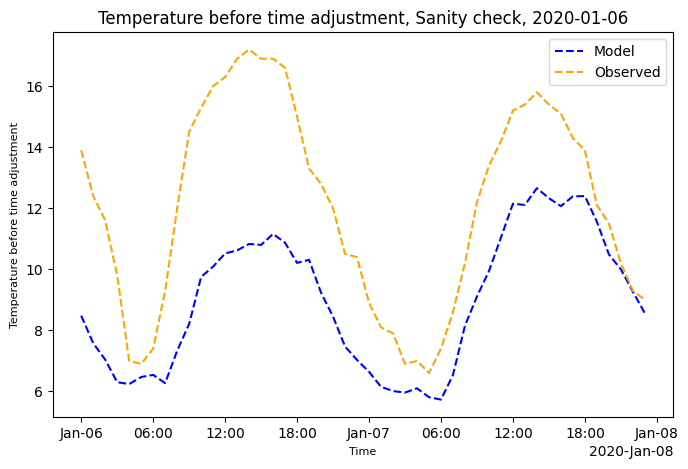

In [50]:
# Sanity check: are both datasets in NZ time zone?
# If they are the the temperatures should peak just after midday rather than midnight.
stn = STATIONS['Glentanner']
d = { 'start_date': "2020-01-06", 'end_date': "2020-01-07" }
obs = np.squeeze(stn['dataset'].temperature.sel(time=slice(d['start_date'], d['end_date'])))
pred = extract_model_series('T', d['start_date'], d['end_date'], stn['location'])

# Verify visually
fig, ax = plt.subplots(1, 1, figsize=(8,5))
plot_model_vs_observations(pred, obs, 'Sanity check', d["start_date"], 'Temperature before time adjustment', ax)
plt.show()


## Q3: Calculate RMSE, R squared, and IoA

> Write code that calculates the RMSE, IOA, and R-square validation metrics. Your n (refer to the
> reading material document) should be the total number of observations in the week period.
> Report your results using a table

The code below makes use of the HydroErr package for calculation of metrics, and Pandas to create a DataFrame for conveniently displaying the data in a table.


In [51]:
def get_observations_and_predictions(obs_key, pred_key, stn, dr):
  obs = np.squeeze(stn['dataset'][obs_key].sel(time=slice(dr['start_date'], dr['end_date'])))
  pred = extract_model_series(pred_key, dr['start_date'], dr['end_date'], stn['location'])
  assert len(obs) == len(pred)
  return obs, pred

In [52]:
import pandas as pd
import HydroErr

# Accumulators for the three variables
rh = []
t = []
ws = []

d1 = DATE_RANGES[0]
d2 = DATE_RANGES[1]

def build_row(key, variable, obs1, pred1, obs2, pred2):
  row = {
      'Location': key,
      'Variable': variable,
      'RMSE Jan': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'IOA Jan': HydroErr.HydroErr.d(pred1.values, obs1.values),
      'R SQUARED Jan': HydroErr.HydroErr.r_squared(pred1.values, obs1.values),
      'RMSE Jul': HydroErr.HydroErr.rmse(pred2.values, obs2.values),
      'IOA Jul': HydroErr.HydroErr.d(pred2.values, obs2.values),
      'R SQUARED Jul': HydroErr.HydroErr.r_squared(pred2.values, obs2.values),
  }
  return row

# For each location
for k_ix, key in enumerate(STATIONS.keys()):
  stn = STATIONS[key]

  # Create a relative humidity row
  rh_obs1, rh_pred1 = get_observations_and_predictions('relative_humidity', 'RH', stn, d1)
  rh_obs2, rh_pred2 = get_observations_and_predictions('relative_humidity', 'RH', stn, d2)
  rh_row = build_row(key, 'RH', rh_obs1, rh_pred1, rh_obs2, rh_pred2)
  rh.append(rh_row)

  # Create a temperature row
  t_obs1, t_pred1 = get_observations_and_predictions('temperature', 'T', stn, d1)
  t_obs2, t_pred2 = get_observations_and_predictions('temperature', 'T', stn, d2)
  t_row = build_row(key, 'T', t_obs1, t_pred1, t_obs2, t_pred2)
  t.append(t_row)

  # Create a wind speed row
  ws_obs1, ws_pred1 = get_observations_and_predictions('wind_speed', 'WS', stn, d1)
  ws_obs2, ws_pred2 = get_observations_and_predictions('wind_speed', 'WS', stn, d2)
  ws_row = build_row(key, 'WS', ws_obs1, ws_pred1, ws_obs2, ws_pred2)
  ws.append(ws_row)

statistics = pd.DataFrame(rh + t + ws)
statistics

,Location,Variable,RMSE Jan,IOA Jan,R SQUARED Jan,RMSE Jul,IOA Jul,R SQUARED Jul
0,Southbridge,RH,18.176009,0.753635,0.625788,9.993523,0.749596,0.377793
1,Glentanner,RH,19.490305,0.614249,0.146261,14.770370,0.614602,0.273786
2,Southbridge,T,2.543971,0.930070,0.809305,2.155090,0.901507,0.685838
3,Glentanner,T,3.503258,0.779664,0.606544,2.212541,0.764893,0.428470
4,Southbridge,WS,2.207541,0.738001,0.384923,1.672844,0.726383,0.308287
5,Glentanner,WS,2.843924,0.764872,0.365526,2.210997,0.606283,0.138195


 ## Q4: Visualise the data

> Produce time series plots of observed and modelled meteorological variables at both
> locations. Your plots should demonstrate a one to one comparison and their objective is to
> visualize the trend and biases while investiga

The below function defines a helper to plot both the model and observation data for a given parameter and date range.

In [ ]:
def plot_model_vs_observations(model_data, obs_data, key, month, data_type, ax):
    model_data.plot(ax=ax, linestyle="dashed",color="blue",label="Model")
    obs_data.plot(ax=ax, linestyle="dashed",color="orange",label="Observed")
    ax.set_xlabel("Time", fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_ylabel(data_type, fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_title(f"{data_type}, {key}, {month}")
    ax.legend()
    

Generate the comparison plots. Chosen weeks are the week starting Jan 6th 2020, and the week starting July 10th 2019.

In [ ]:
fig, axs = plt.subplots(6, 2, figsize=(14,20))

ax_y = 0
for d_ix, date_range in enumerate(DATE_RANGES):
    start_date = date_range['start_date']
    end_date = date_range['end_date']

    ax_y = d_ix * 3
    
    for k_ix, key in enumerate(STATIONS.keys()):
      stn = STATIONS[key]
      dataset_observations = stn['dataset']
      time_slice_observed = dataset_observations.sel(time=slice(start_date, end_date))

      rh_obs, rh_model = get_observations_and_predictions('relative_humidity', 'RH', stn, date_range)
      plot_model_vs_observations(rh_model, rh_obs, key, start_date, 'RH', axs[ax_y+0][k_ix])
    
      # Model temperatures are in kelvin so need to be converted
      t_obs, t_model = get_observations_and_predictions('temperature', 'T', stn, date_range)
      plot_model_vs_observations(t_model, t_obs, key, start_date, 'T', axs[ax_y+1][k_ix])
    
      # Wind speed in the WRF data is in two directions and need to be combined
      ws_obs, ws_model = get_observations_and_predictions('wind_speed', 'WS', stn, date_range)     
      plot_model_vs_observations(ws_model, ws_obs, key, start_date, 'WS', axs[ax_y+2][k_ix])

plt.subplots_adjust(hspace=1.0)
plt.show()

### Discussion of the above results

#### Southbridge

Relative humidity:
IoA is fairly high for both weeks (0.75, 0.77). You can confirm this visually in that the graph shapes track each other quite closely without any large outliers.
RMSE fairly high (16%) in January, which you can see on the graph in that the observed line is sitting higher than the predicted line all the way across the time period. IoA is quite high though, since there were no big spikes in the difference.
R squared is better in January (0.63) than July (0.43) where you can see the strong dip in the model on July 15. January's Rsquared would have been better if not for the gaps between model & prediction around the 6th, 10th, and 11th.

Temperature:

IoA is high in both periods (in the 90s)
RMSE is pretty low - about 2 degrees for both periods.
But Rsquared is very low! TODO why?

Wind speed:
IoA for wind speed was much higher for January than for July - on July 13th 2019 there was a strong wnd watch issued by met service. a severe weather system moved through Canterbury on the 13th-14th. This would explain the IoA for that period being only 46%.  IoA is sensitive to large outliers or extreme weather events. You can see the wind speed peak in the observed line on the July graph.
RMSE is around 2 m/s for both periods - averaging errors accross the time period covers up the outlier in July. 
R squared is low for both periods, but very low (0.01) for July. R squared focuses on trend matching, so the wind event in July would affect it strongly.

#### Glentanner

RH:
Visually both periods totally different between model & observations! The observed data is much more variable than the predicted data. 
17% and 15% RMSE which isn't that much higher than Southbridge's RH values.
IoAs in the 0.6's, but R Squared really low (0.23, 0.26). 




## Q5: Scatter plots

> Produce scatter plots of observed and modelled meteorological variables for both locations.
> Add a linear trend line that best fits the data points and report the equation of the line. For
> reference this is similar to the green lines in the case studies presented in the reading material
> handout. Describe and discuss your results.

In [ ]:
def scatter_plot(ax, observations, predictions, start_date, location, variable, variable_stats):
    slope, intercept, rvalue, pvalue, stderr = stats.linregress(observations.values, predictions.values)
    regression_line = slope * t_obs + intercept

    ax = axs[k_ix][d_ix]

    ax.scatter(observations.values, t_pred.values)
    ax.plot(observations, observations, color='red', linestyle='--',  label=f'1:1 line')
    ax.plot(observations, regression_line, color='green', label=f'Fit: P = {intercept:.2f} + {slope:.2f}*O')
    ax.grid(True, linestyle='--')
    ax.set_title(f'{location} {variable} week of {start_date}', loc='left', pad=25)
    
    # Add subtitle with R2, RMSE, IoA, and Bias
    location_stats = variable_stats.loc[variable_stats['Location'] == key]
    stat_col = 'Jan' if d_ix == 0 else 'Jul'
    rmse = location_stats[f'RMSE {stat_col}'].item()
    r2 = location_stats[f'R SQUARED {stat_col}'].item()
    ioa = location_stats[f'IOA {stat_col}'].item()
    mean_bias = (t_pred - t_obs).mean()
      
    ax.text(0.0, 1.02, f'R2={r2:.2f} RMSE={rmse:.2f} IOA={ioa:.2f} Bias={mean_bias:.2f}', transform=ax.transAxes, fontsize=8, color='gray')
    ax.legend(loc='upper left')
    ax.set_xlabel('Observed')
    ax.set_ylabel('Modelled')

### 5a: Temperature

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))
temp_rows = statistics.loc[statistics['Variable'] == 'T']

for k_ix, key in enumerate(STATIONS.keys()):
  stn = STATIONS[key]
  d_ix = 0

  for d_ix, d in enumerate(DATE_RANGES):
    t_obs, t_pred = get_observations_and_predictions('temperature', 'T', stn, d)
    ax = axs[k_ix][d_ix]
    scatter_plot(ax, t_obs, t_pred, d['start_date'], key, 'temperature', temp_rows)
      
plt.subplots_adjust(hspace=0.5)
plt.show()

### 5b: Relative humidity

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))
stat_rows = statistics.loc[statistics['Variable'] == 'RH']

for k_ix, key in enumerate(STATIONS.keys()):
  stn = STATIONS[key]
  d_ix = 0

  for d_ix, d in enumerate(DATE_RANGES):
    t_obs, t_pred = get_observations_and_predictions('relative_humidity', 'RH', stn, d)
    ax = axs[k_ix][d_ix]
    scatter_plot(ax, t_obs, t_pred, d['start_date'], key, 'relative humidity', stat_rows)
      
plt.subplots_adjust(hspace=0.5)
plt.show()

### 5c: Wind speed

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))
stat_rows = statistics.loc[statistics['Variable'] == 'WS']

for k_ix, key in enumerate(STATIONS.keys()):
  stn = STATIONS[key]
  d_ix = 0

  for d_ix, d in enumerate(DATE_RANGES):
    t_obs, t_pred = get_observations_and_predictions('wind_speed', 'WS', stn, d)
    ax = axs[k_ix][d_ix]
    scatter_plot(ax, t_obs, t_pred, d['start_date'], key, 'wind speed', stat_rows)

plt.subplots_adjust(hspace=0.5)
plt.show()

### Scatter plots discussion

Relative humidity values in Southbridge show a near-constant bias of -20% in January. For all other locations and date ranges there is no constant bias.

Highest IoA (0.93) is shown in Southbridge temperature for January. This is also the best performance overall.

Worst overall is a tie between Glentanner winter relative humidity (r2=0.15, IoA=0.61) and Glentanner summer wind speed (r2=0.14, IoA=0.61).


# Part B

Objective: This part aims to extend the analysis carried out in part B over a longer period of time. We will aim to evaluate the WRF model over a 5-year period (choose any 5-year period) against observations. The observational data from the MetService weather station network can be found on the Sky server folder /mnt/data/MetService_AWS. This will allow us to develop a better understanding of the structure of the bias in relationship to meteorological processes occurring on diurnal and monthly periods. Continue using the same Jupyter notebook to add well commented (using markdown and in-cell comments) sections that full fill the following requirements.

### 1. 

We will evaluate WRF model based on its performance for coastal, inland, and high elevation sites. Pick two regional council geographic areas (https://en.wikipedia.org/wiki/Regions_of_New_Zealand#/media/File:NZ_Regional_Councils _and_Territorial_Authorities_2017.svg)
from each island and select weather stations from each region for a coastal (low elevation), inland (low elevation), and a high elevation site (>500m ASL if available). You will end up with 12 weather stations across both islands. 

Summarize your locations in a markdown cell and/or use a table to present them. To assist your search use the MetService weather station map from here https://www.metservice.com/maps-radar/weather-stations/nz/ along with the lat/long/names of station from the netCDF files here /mnt/data/MetService_AWS.


#### Selected locations

|Island|Region|Location|Approximate elevation|Latitude|Longitude|
|---|---|---|---|---|---|
|North Island|Waikato|Port Taharoa AWS|25m|-38.166|174.705|
|North Island|Waikato|Paeroa AWS|18m|-37.371|175.684|
|North Island|Waikato|Rotorua Airport|285m|-38.106|176.315|
|North Island|Manawatū-Whanganui|Wanganui Airport|8m|-39.961°|175.026°|
|North Island|Manawatū-Whanganui|Ohakea AWS|50m|-40.196°|175.381|
|North Island|Manawatū-Whanganui|Waiouru Aero|819.0|-39.446|175.658|
|South Island|Canterbury|New Brigton Pr|8m|-43.506°|172.734°|
|South Island|Canterbury|Timaru Airport|27m|-44.305°|171.221°|
|South Island|Canterbury|Sugar Loaf AWS|496.0|-43.604|172.649|
|South Island|Otago|Nugget Point AWS|131m|-46.448°|169.812°|
|South Island|Otago|Roxburgh WXT AWS|154m|-45.517°|169.313°|
|South Island|Otago|Swampy Summit AWS|716.0|-45.801|170.477|




## 2.

Use the GroupBy function in xarray to help you organize your dataset arrays into monthly groups and then hourly groups. Provide a comprehensive model validation of each of the 12 selected station points using the RMSE, IOA, and R-square values. The validation should be carried out on a monthly basis (so 12 groups in total), and a diurnal basis (per hour of a day, so 24 groups). 

In [11]:
import glob
import xarray as xr

FILE_NAMES = [
    # Waikato
    'Port Taharoa AWS.nc',    'Paeroa AWS.nc',       'Rotorua Aero AWS.nc', 
    # Manawatu
    'Wanganui Aero AWS.nc',   'Ohakea AWS.nc',       'Waiouru Aero.nc',
    # Canterbury
    'New Brighton Pr WXT.nc', 'Sugar Loaf AWS.nc',   'Timaru Airport AWS.nc',
    # Otago
    'Nugget Point AWS.nc',    'Roxburgh WXT AWS.nc', 'Swampy Summit AWS.nc',
]

START_DATE = '2013-01-01'
END_DATE = '2017-12-31'

def read_wrf_files(data_type, location, height=2):
    dataset = None
    start_file = f"{data_type}_20130101000000.nc"
    end_file = f"{data_type}_20171201000000.nc"
    all_files = sorted(glob.glob(f"/mnt/data/MetService_WRF/{data_type}_*.nc"))
    file_list = [
        f for f in all_files if start_file <= f.split("/")[-1] <= end_file
    ]        
    print('got file list')
    dataset = xr.open_mfdataset(file_list, combine="by_coords")
    print('opened combined dataset')

    if (dataset):
        dataset = dataset.sel(height=height, lat=location['lat'], lon=location['lon'], method="nearest")
        if (data_type == 'T'):
            dataset = dataset - 273.15

    # Convert times to NZ local time
    dataset = to_nz_time(dataset)
    return dataset

def data_for_location(fn):
    dataset = xr.open_dataset(f"/mnt/data/MetService_AWS/{fn}")

    # Extract observed data sliced by time
    obs_time_slice = slice(START_DATE, END_DATE)
    t_obs = dataset.temperature.sel(time=obs_time_slice).drop_duplicates(dim='time').drop_vars('height', errors='ignore')
    rh_obs = dataset.relative_humidity.sel(time=obs_time_slice).drop_duplicates(dim='time').drop_vars('height', errors='ignore')
    ws_obs = dataset.wind_speed.sel(time=obs_time_slice).drop_duplicates(dim='time').drop_vars('height', errors='ignore')

    # Fetch predicted data (Ensure these return Xarray DataArrays with a matching 'time' coordinate)
    loc_coords = {"lat": dataset.latitude, "lon": dataset.longitude}
    t_mod = read_wrf_files("T", loc_coords).drop_duplicates(dim='time').drop_vars('height', errors='ignore').T
    rh_mod = read_wrf_files("RH", loc_coords).drop_duplicates(dim='time').drop_vars('height', errors='ignore').RH
    u_mod = read_wrf_files("U", loc_coords, height=10).drop_duplicates(dim='time').drop_vars('height', errors='ignore')
    v_mod = read_wrf_files("V", loc_coords, height=10).drop_duplicates(dim='time').drop_vars('height', errors='ignore')
    u_arr = u_mod.to_dataarray()
    v_arr = v_mod.to_dataarray()
    ws_mod = np.sqrt(u_arr**2 + v_arr**2)

    # Combine everything into a single aligned dataset
    stn_dataset = xr.Dataset(
        data_vars={
            "temp_obs": t_obs,
            "temp_mod": t_mod,
            "rh_obs": rh_obs,
            "rh_mod": rh_mod,
            "ws_obs": ws_obs,
            "ws_mod": ws_mod,
        }
    )
    return stn_dataset

In [13]:
obs_time_slice = slice(START_DATE, END_DATE)
obs_dataset = xr.open_dataset('/mnt/data/MetService_AWS/Sugar Loaf AWS.nc')
# t_obs = dataset.temperature.sel(time=obs_time_slice).drop_duplicates(dim='time').drop_vars('height', errors='ignore')

loc_coords = {"lat": obs_dataset.latitude, "lon": obs_dataset.longitude}

t_mod = read_wrf_files("T", loc_coords)
t_mod = t_mod.drop_duplicates(dim='time')
t_mod = t_mod.drop_vars('height', errors='ignore')
t_mod.T.values

got file list
opened combined dataset


KeyboardInterrupt: 

In [12]:
data_for_location('Sugar Loaf AWS.nc')

got file list
opened combined dataset
got file list
opened combined dataset
got file list
opened combined dataset
got file list
opened combined dataset


<xarray.Dataset> Size: 2MB
Dimensions:   (time: 43824, variable: 0)
Coordinates:
  * time      (time) datetime64[ns] 351kB 2013-01-01T13:00:00 ... 2018-01-01T...
    lat       float64 8B -43.61
    lon       float64 8B 172.7
  * variable  (variable) object 0B 
Data variables:
    temp_obs  (time) float64 351kB nan nan nan nan nan ... nan nan nan nan nan
    temp_mod  (time) float64 351kB dask.array<chunksize=(729,), meta=np.ndarray>
    rh_obs    (time) float64 351kB nan nan nan nan nan ... nan nan nan nan nan
    rh_mod    (time) float64 351kB dask.array<chunksize=(729,), meta=np.ndarray>
    ws_obs    (time) float64 351kB nan nan nan nan nan ... nan nan nan nan nan
    ws_mod    (variable, time) float64 0B

### Monthly performance: RMSE by station

In [36]:
loc_coords = { 'lat': -38.166, 'lon': 174.705 }
ws_mod = read_wrf_files("WS", loc_coords).drop_duplicates(dim='time').to_dataarray()
ws_mod


IndexError: list index out of range

In [ ]:
def build_monthly_row(key, variable, obs1, pred1, obs2, pred2):
  row = {
      'Location': key,
      'Variable': variable,
      'January': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'February': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'March': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'April': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'May': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'June': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'July': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'August': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'September': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'October': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'November': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
      'December': HydroErr.HydroErr.rmse(pred1.values, obs1.values),
  }
  return row

variable_map = {
    'Temperature': ('t_obs', 't_pred'),
    'Relative humidity': ('rh_obs', 'rh_pred'),
    'Wind speed': ('ws_obs', 'ws_pred'),
}

# Create MultiIndexes for Pandas rows
row_index = pd.MultiIndex.from_product(
    [stations, variables, metrics], names=["Station", "Variable", "Metric"]
)

# Initialize blank DataFrames for Monthly (12 cols) and Diurnal (24 cols)
monthly_df = pd.DataFrame(index=row_index, columns=range(1, 13))

stat_rows = []

for fn in FILE_NAMES:
    dataset = data_for_location(fn)
    
     for var_name, (obs_key, mod_key) in var_map.items():
        # Drop nan values to ensure clean statistical matching
        valid_data = dataset[[obs_key, mod_key]].dropna(dim="time")

        # --- 1. Monthly GroupBy Processing ---
        monthly_groups = valid_data.groupby("time.month")
        for month, group in monthly_groups:
            obs = group[obs_key].values
            mod = group[mod_key].values

            if len(obs) > 1:  # Ensure we have data points to compare
                monthly_df.loc[(stn, var_name, "RMSE"), month] = calc_rmse(
                    obs, mod
                )
                monthly_df.loc[(stn, var_name, "IOA"), month] = calc_ioa(
                    obs, mod
                )
                monthly_df.loc[(stn, var_name, "R2"), month] = calc_rsquared(
                    obs, mod
                )
    
    t_monthly_obs = dataset['temperature']['observed'].groupby('time.month')
    t_monthly_pred = dataset['temperature']['predicted'].groupby('time.month')
    #rh_monthly_obs = dataset['relative_humidity']['observed'].groupby('time.month')
    #rh_monthly_pred = dataset['relative_humidity']['predicted'].groupby('time.month')
    #ws_monthly_obs = dataset['wind_speed']['observed'].groupby('time.month')
    #ws_monthly_pred = dataset['wind_speed']['predicted'].groupby('time.month')




In [17]:
# Monthly data
t_obs = ds['temperature']['observed']
t_pred = ds['temperature']['predicted']
t_obs_grp = t_obs.groupby('time.month')
t_pred_grp = t_pred.groupby('time.month')

# how many observations should there be? (5 years * 365 days * 24 hours) +1 for the leap year in 2016
expected_data_points = (5 * 365 * 24) + 1
print(expected_data_points) # 43801

# observations: 40788, missing 3012 hours/125 days
# predictions: 43801


43801


In [20]:
ds['wind_speed']['observed']

<xarray.DataArray 'wind_speed' (time: 40788)> Size: 326kB
[40788 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 326kB 2013-04-15 ... 2017-12-31T23:00:00
Attributes:
    long_name:      wind speed
    standard_name:  wind_speed
    units:          m s-1

<xarray.DataArray 'temperature' (time: 40788)> Size: 326kB
[40788 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 326kB 2013-04-15 ... 2017-12-31T23:00:00
Attributes:
    long_name:      air temperature
    standard_name:  air_temperature
    units:          degC

### 2a.

Produce boxplots of modelled and observed parameters (not the validation metrics). The presentation of the results should allow for a one-to-one comparison of the underlying Gaussian statistics that the boxplot can provide. This is to be done for monthly and diurnal grouped data. Describe and discuss your results

## 2b.

Produce a table that summarizes the IOA, RMSE, and R-square values for each weather  stations location and for both diurnal and monthly groups. Describe and discuss your results.